# Caladan Takehome Assignment 

TASKS: 
1. IDENTIFY FEATURES THAT HAVE STRONG PREDICTIVE POWER 
2. PREDICTION HORIZON ANALYSIS 
   * Explore how signal performance varies across different time horizons.
   * Evaluate signal decay and discuss your choice of optimal horizon for predictive trading.
3. PREDICTION MODEL CONSTRUCTION 
   * Construct a composite signal from selected features or model for price prediction
   * Evaluate the composite signal's robustness and stability.
4. REGIME ANALYSIS 
   * Analyze how your signal performs under different market conditions
   * Identify if your signal is stationary or regime-sensitive.
   * Propose improvements or filtering techniques to enhance reliability.


In [18]:
import pandas as pd 
import numpy as np 
import matplotlib 
import matplotlib.pyplot as plt 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge 
from sklearn.decomposition import PCA 
from scipy.stats import spearmanr


## Data Prep 
To make sense of data, we check 
1. understand the data
2. check for missing, nan values.
3. check timestep 
4. check distribution of clipped data 
5. check collinearity of features 

In [19]:
def get_data(): 
    '''
    gets data from parquet file provided. conducts data sanity checks to 
    1. understand the data
    2. check for missing, nan values.
    3. check timestep 
    4. check distribution of clipped data 
    5. check collinearity of features 
    '''
    df  = pd.read_parquet("feature.parq", engine="pyarrow")
    data = df.copy()
    # understanding data 
    print("Data Description:", data.describe())
    print("\n")
    # check for missing, nan values 
    print("Missing value check :", data.isna().mean().sort_values(ascending=False).head(15))
    print("\n")

    # check timestep, coverage, gaps (are gaps really all 1 sec?)
    print("Timestamp check: ")
    print(f"Data Start: {data.index.min()}, Data End: {data.index.max()}")
    print("\n")
    print("Check Increasing index:", data.index.is_monotonic_increasing)
    print("\n")
    print("Gap count in timestamp: ", data.index.to_series().diff().value_counts().head(5))
    print("\n")
    # check data clipping: is most of feature values concentrated at +- 5? 
    feat_cols = [c for c in data.columns if c != "mid_prc"]
    clip_rate = ((data[feat_cols].abs() >= 4.999).mean()).sort_values(ascending=False)
    print("check clipping: ", clip_rate.head(15))
    print("\n")
    # check collinearity between features timeseries 
    sample = data.sample(50000, random_state=0) # random sample of rows 
    corr = sample[feat_cols].corr().abs()
    neighbors = (corr > 0.98).sum().sort_values(ascending=False).head(15) # the average number of neighbours that each feature has. 
    # if this number is low --> features are not that collinear. 
    print("Check Collinearity:", neighbors)
    return df
    
data = get_data()


Data Description:              mid_prc     b66accf4d4     01d830fc33     ac29aa28b0  \
count  604378.000000  604378.000000  604378.000000  604378.000000   
mean     1601.856689      -0.001573       0.000471       0.000961   
std        33.063606       1.002640       1.000666       0.999296   
min      1536.010010      -5.000000      -5.000000      -5.000000   
25%      1581.724976      -0.673479      -0.634930      -0.610623   
50%      1591.655029      -0.007083      -0.004322       0.000993   
75%      1612.604980       0.664406       0.633471       0.612619   
max      1777.680054       5.000000       5.000000       5.000000   

          86eecbe036     9c51f3cf1d     706dbe6d28     cb232e1c9f  \
count  604378.000000  604378.000000  604378.000000  604378.000000   
mean        0.000961      -0.003787      -0.004580      -0.002970   
std         0.999296       1.005991       1.007335       1.004184   
min        -5.000000      -5.000000      -5.000000      -5.000000   
25%        -0.6

## Comments on Data: 
Key observations 
* Data timestamps are strictly increasing, and mostly in one second gaps, some 413 2 second gaps and 2 3 second gaps. 
* No missing values in data set, seems to be already standardized to normal (0,1)
* Data is sufficiently non collinear - each feature has maximum 4 correlated neighbours on average. 
* Although clipped, seems like there is not many extreme cases, a $\pm 5$ value truly captures how extreme this signal is. 


## Task 1: Identifying features with strong predictive power 

In [20]:
def train_test(data):
    dates = data.index.normalize()
    unique_days = sorted(dates.unique())
    train_days, val_days, test_days = unique_days[:5], unique_days[5:6], unique_days[6:7]

    train_mask = dates.isin(train_days)
    val_mask   = dates.isin(val_days)
    test_mask  = dates.isin(test_days)

    return train_mask, val_mask, test_mask


def log_horizon_returns(H, data): 
    '''
    contruct future returns based on target horizon H
    '''
    mid_price = data["mid_prc"]
    m = np.log(mid_price)
    out = {}
    for h in H: 
        target = data.index + pd.Timedelta(seconds= h)
        out[f"h={h}"] = m.reindex(target).values - m.values
    return pd.DataFrame(out, index=data.index)

def pearson_ic(h_rets, H, data):
    '''
    For each horizon h and each feature, compute Pearson IC
    ''' 
    feat = data.drop(columns=["mid_prc"])
    out = {}
    for h in H:
        col = f"h={h}"
        r = h_rets[col]
        out[col] = feat.corrwith(r)       
    return pd.DataFrame(out)

def spearman_rank_ic(h_rets, H, data): 
    '''
    For each horizon h and each feature, compute the spearman IC 
    '''
    feat = data.drop(columns=["mid_prc"])
    out = {}
    for h in H:
        col = f"h={h}"
        r = h_rets[col]
        out[col] = feat.corrwith(r, method="spearman")
    return pd.DataFrame(out)


def feature_rank(sic, top_n): 
    '''
    Ranking Spearman information coefficient
    '''
    mean_sic= sic.abs().mean(axis=1)
    top_features = mean_sic.nlargest(top_n).index.tolist()

    # view feature decay 
    curves = sic.loc[top_features].copy()
    plt.figure()
    for feat in curves.index:
        plt.plot(curves.columns, curves.loc[feat].values.abs(), marker="o", label=feat)

    plt.xlabel("Horizon (seconds)")
    plt.ylabel("|Spearman IC|")
    plt.title(f"Top {top_n} feature IC decay curves")
    plt.grid(True)
    plt.show()
    return top_features

def decile_plot(top_features, data, horizon, H): 
    '''
    decile plots for extracted top features. 
    '''
    log_ret_data = log_horizon_returns(H, data)
    target_col_name = f"h={horizon}"
    features_to_plot = top_features[:5]
    n_feats = len(features_to_plot)
    
    fig, axes = plt.subplots(1, n_feats, figsize=(4 * n_feats, 4), sharey=True)
    if n_feats == 1: axes = [axes] # Handle single plot case
    
    print(f"Generating Decile Plots for Horizon: {horizon}s...")

    for i, feature in enumerate(features_to_plot):
        ax = axes[i]
        
        # temp df 
        df_temp = pd.DataFrame({
            'feature': data[feature],
            'target': log_ret_data[target_col_name]
        }).dropna()
        
        try:
            df_temp['Decile'] = pd.qcut(df_temp['feature'], 10, labels=False, duplicates='drop')
        except ValueError:
            ax.text(0.5, 0.5, "Bad Data", ha='center', transform=ax.transAxes)
            continue

        decile_means = df_temp.groupby('Decile')['target'].mean() * 10000
        
        # plot
        decile_means.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black', width=0.8)
        
        # formatting
        ax.set_title(feature, fontsize=10, fontweight='bold')
        ax.set_xlabel("Decile")
        ax.axhline(0, color='black', linewidth=0.8)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Y-Label only on first chart
        if i == 0:
            ax.set_ylabel(f"Mean Return {horizon}s (bps)")
        else:
            ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


def choose_h_star(sic_train, sic_val, H, K=20):
    '''
    choose optimal horizon
    1. for each possible h, take top k feature on train set by abs(IC)
    2. compare how well each of these top k perform on validation set. 
    '''
    scores = {}
    for h in H:
        col = f"h={h}"
        topK = sic_train[col].abs().nlargest(K).index
        scores[h] = sic_val.loc[topK, col].abs().median()
        h_star = max(scores, key=scores.get) # type: ignore
    h_scores = pd.Series(scores).sort_values(ascending=False)

    h_star = h_scores.index[0]
    runner = h_scores.index[1] 
    gap = (h_scores.iloc[0] - h_scores.iloc[1]) 

    print(f"Most optimal h: {h_star}")
    print(h_scores)

    print("winner:", h_star, "runner-up:", runner)
    print("gap:", gap)

    return h_star, h_scores

def model_ic(pred, y):
    return np.corrcoef(pred, y)[0, 1]

def choose_n_feat(sic_train, h_rets, h_star, n_choice, train_d, val_d, data, alpha): 
    col = f"h={h_star}"
    y = h_rets[col]
    out = []
    for n in n_choice:
        feats = sic_train[col].abs().nlargest(n).index
        X = data[feats]

        # alignmnent 
        X_tr = X.loc[train_d]
        y_tr = y.loc[train_d].dropna()
        idx = X_tr.index.intersection(y_tr.index)
        X_tr, y_tr = X_tr.loc[idx], y_tr.loc[idx]

        Xv = X.loc[val_d]
        yv = y.loc[val_d].dropna()
        idxv = Xv.index.intersection(yv.index)
        Xv, yv = Xv.loc[idxv], yv.loc[idxv]

        # run a ridge regression for Best N features. 
        m = Ridge(alpha=alpha)
        m.fit(X_tr, y_tr)
        pred = m.predict(Xv)

        # Score
        ic_score = model_ic(pred, yv.values)
        out.append((n, ic_score))

    res = pd.DataFrame(out, columns=["N", "val_model_ic"]).set_index("N")
    best = res["val_model_ic"].max()
    N_star = res[res["val_model_ic"] >= 0.95 * best].index.min()
    print(f"Optimal N selected: {N_star} (Peak IC: {best:.4f})")
    
    return N_star, res

def feature_selection(data, H, k): 
    train_d, val_d, test_d = train_test(data)
    h_rets =log_horizon_returns(H, data)

    h_rets_train = h_rets.loc[train_d]
    sic_train = spearman_rank_ic(h_rets_train, H, data[train_d])
    data_train = data.loc[train_d]

    h_rets_val = log_horizon_returns(H, data[val_d])
    sic_val = spearman_rank_ic(h_rets_val, H, data[val_d])
    h_star, h_scores = choose_h_star(sic_train, sic_val, H, K=k)

    N_star, N_curve = choose_n_feat(
        sic_train, h_rets, h_star, [5,10,15,20], train_d, val_d, data, 0.4
    ) 
    

    return h_star, h_scores, N_star, N_curve, (train_d, val_d, test_d), h_rets, sic_train


Most optimal h: 1
1      0.152426
2      0.122268
3      0.102287
4      0.086352
5      0.074977
10     0.050499
50     0.018863
100    0.011057
200    0.010766
dtype: float64
winner: 1 runner-up: 2
gap: 0.030158102764105493
Optimal N selected: 10 (Peak IC: 0.1311)
Generating Decile Plots for Horizon: 1s...


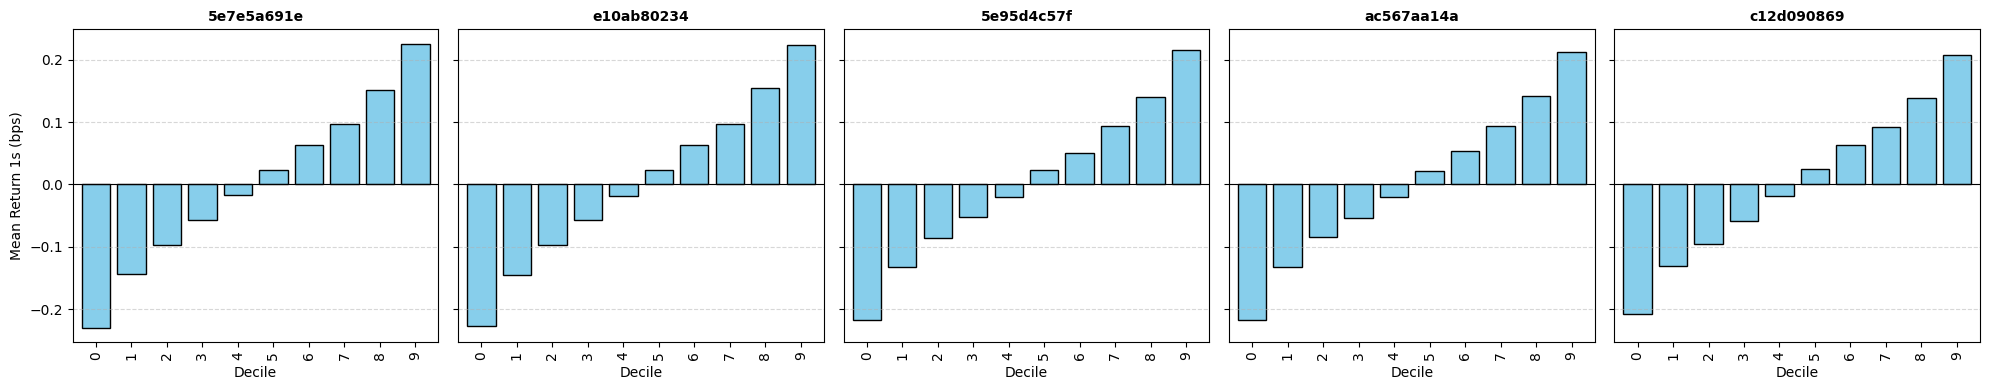

In [21]:
h_star, h_scores, N_star, N_curve, (train_d, val_d, test_d), h_rets, sic_train = feature_selection(data, [1,2,3,4,5,10,50,100,200], 20)

col = f"h={h_star}"
top_feats = sic_train[col].abs().nlargest(N_star).index.tolist()

decile_plot(top_feats, data, horizon=h_star, H=[1,2,3,4,5,10,50,100,200])

## Comments 
* Top 5 feature plots are strongly increasing from left to right --> features have a monotonic positive relationship with this $10s$ ahead return. 

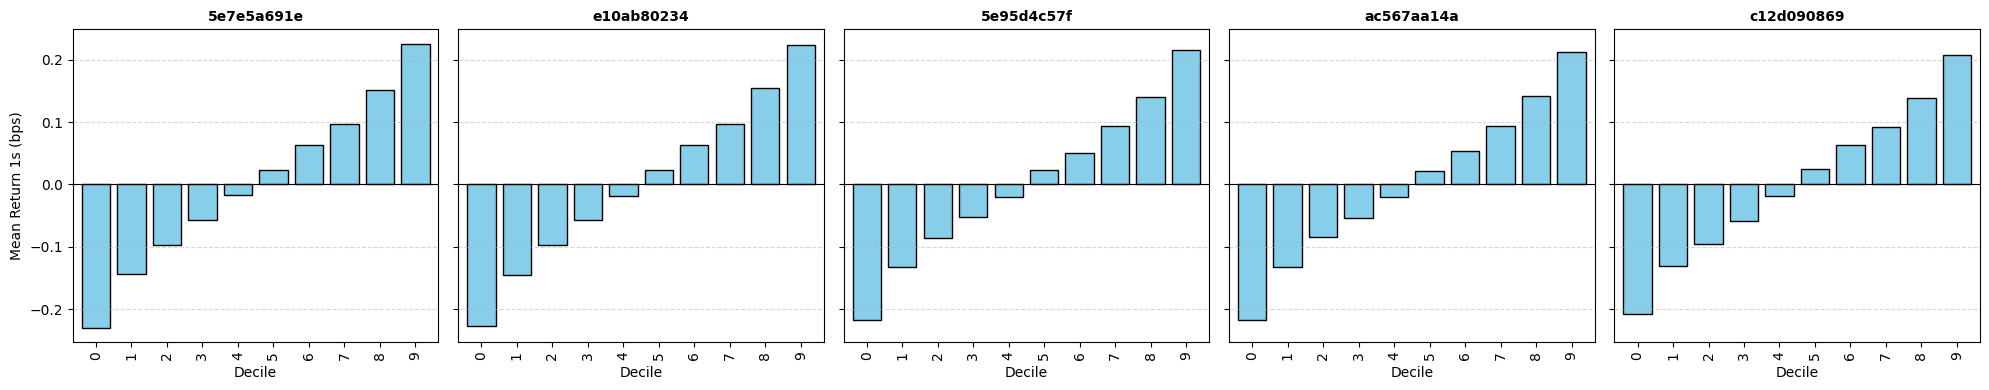

In [22]:
def main(): 
    pass